What is LangChain?
LangChain is an open‑source framework designed to simplify the development of applications that use large language models (LLMs). It provides a set of modular components and standard interfaces for chaining together LLMs with other tools, data sources, and memory.


Why was LangChain introduced?

LangChain was introduced because developers needed:

1️⃣ A structured way to build LLM applications
2️⃣ Reusable components (prompts, models, memory, tools)
3️⃣ Easy integration with databases & vector stores
4️⃣ A standard architecture instead of custom code everywhere
5️⃣ Model-agnostic design (switch Groq → OpenAI → Ollama easily)


### What problems does it solve?
Abstraction over LLM providers – same interface for OpenAI, Anthropic, Groq, open‑source models, etc.

Prompt management – templates, few‑shot examples, partial formatting.

Chaining – compose multiple steps into a single pipeline (e.g., retrieve → generate).

Memory – store and retrieve conversation history in various forms (buffer, summary, vector store).

Agents – let the LLM decide which tools to use and in what order.

RAG pipelines – easily combine retrievers and LLMs for question answering over your data.

Observability – built‑in callbacks for logging, monitoring, and tracing.



In [9]:
### How is it different from calling an LLM API directly?
from groq import Groq
import os
from dotenv import load_dotenv

load_dotenv()

client = Groq(api_key=os.getenv("GROQ_API_KEY"))

response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[{"role": "user", "content": "Hello"}]
)

print(response.choices[0].message.content)

Hello. It's nice to meet you. Is there something I can help you with or would you like to chat?


In [5]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os

load_dotenv()

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0
)

response = llm.invoke("Hello")
print(response.content)

Hello. It's nice to meet you. Is there something I can help you with or would you like to chat?


In [7]:
import langchain
print(langchain.__version__)

1.2.10


In [8]:
#At first glance, the difference seems small. But the real power comes when you need to add memory, tools, or retrieval:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.chat_history import InMemoryChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory
from dotenv import load_dotenv
import os

load_dotenv()

# 1️⃣ Create LLM
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0
)

# 2️⃣ Create prompt (IMPORTANT: must include history)
prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant."),
    ("human", "{input}")
])

chain = prompt | llm

# 3️⃣ Create memory storage
store = {}

def get_session_history(session_id: str):
    if session_id not in store:
        store[session_id] = InMemoryChatMessageHistory()
    return store[session_id]

# 4️⃣ Attach memory
conversation = RunnableWithMessageHistory(
    chain,
    get_session_history,
    input_messages_key="input",
)

# 5️⃣ Run conversation
conversation.invoke(
    {"input": "Hello, I'm Alice."},
    config={"configurable": {"session_id": "user1"}}
)

response = conversation.invoke(
    {"input": "What's my name?"},
    config={"configurable": {"session_id": "user1"}}
)

print(response.content)

Hello Alice, you've already told me that your name is Alice. Is there anything else you'd like to talk about or ask?


### When should we use LangChain?
    Real‑world use cases
    Chatbots with memory – customer support, personal assistants.
    
    Retrieval‑Augmented Generation (RAG) – question answering over company documents, research papers, knowledge bases.
    
    Agents – automated research assistants that can browse the web, use calculators, run code, etc.
    
    Multi‑step workflows – data extraction, summarisation pipelines, content generation with validation.
    
    Automation – connecting LLMs to internal APIs, databases, and tools.

### When NOT to use LangChain
    Very simple, single‑call applications – if you just need a one‑off LLM call, direct API is simpler.
    
    Low‑latency requirements – the abstraction adds overhead; for high‑frequency, low‑latency use, you might want a more lightweight solution.
    
    Tightly controlled prompts – sometimes you need pixel‑perfect control over the prompt; LangChain's templates are helpful but can be bypassed.
    
    When you’re learning LLMs from scratch – it’s better to first understand the basics of prompting and API calls before adding a framework.

### LangChain Architecture

LangChain is built around several core components. They work together like building blocks.

Core components
Component	Description
LLMs / ChatModels	Wrappers around language models. LLM is for string‑in/string‑out (older models), ChatModel is for message‑in/message‑out (chat models).
Prompts	Templates that format user input into a prompt the model understands. Includes PromptTemplate, ChatPromptTemplate, few‑shot examples.
Chains	Sequences of calls (to LLMs, tools, or other chains). The simplest is LLMChain, but you can build complex pipelines with LCEL.
Runnables	The building block of LCEL. Any component that can be invoked, batched, streamed, or transformed.
Tools	Functions that an agent can call. They have a name, description, and input schema.
Agents	Use an LLM to decide which tools to call and in what order. The agent executes actions and returns the final answer.
Memory	Persists state between interactions. Examples: buffer, summary, vector store, and combinations thereof.
Retrievers	Interfaces to retrieve relevant documents from a vector store or other index.
Vector stores	Store embeddings and support similarity search. Examples: Chroma, FAISS, Pinecone.
Embeddings	Convert text into vectors. Used for retrieval and semantic search.
How they work together – conceptual flow
Imagine you’re building a RAG chatbot:

User query comes in.

Memory retrieves conversation history.

Retriever fetches relevant documents from a vector store (using embeddings).

Prompt template combines the query, history, and documents into a single prompt.

ChatModel (LLM) generates an answer.

Memory updates with the new exchange.

Answer is returned to the user.

All these steps can be composed into a single chain (e.g., using LCEL). An agent would add a loop where the LLM decides to call tools (like a search engine or calculator) before answering.

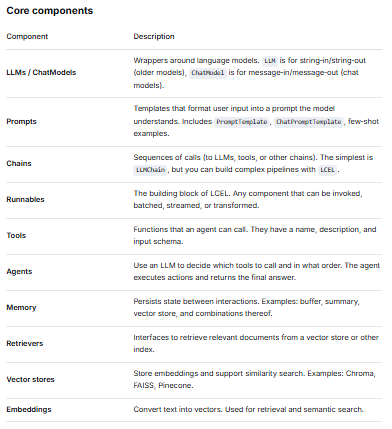

### How they work together – conceptual flow
Imagine you’re building a RAG chatbot:

User query comes in.

Memory retrieves conversation history.

Retriever fetches relevant documents from a vector store (using embeddings).

Prompt template combines the query, history, and documents into a single prompt.

ChatModel (LLM) generates an answer.

Memory updates with the new exchange.

Answer is returned to the user.

All these steps can be composed into a single chain (e.g., using LCEL). An agent would add a loop where the LLM decides to call tools (like a search engine or calculator) before answering.

### Example 

In [11]:
#Basic usage:
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0

)
response = llm.invoke("Explain Langchain in One Sentence")
response.content

'Langchain is an open-source framework that enables the development of applications using large language models, providing a modular and flexible way to integrate AI models into various software projects.'

In [14]:
#With a prompt template:
from langchain_core.prompts import ChatPromptTemplate
prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful AI assistant."),
    ("human", "{input}")
])
chain = prompt | llm
result = chain.invoke({"input":"what is RAG"})
result.content

'RAG can refer to different things depending on the context. Here are a few possible meanings:\n\n1. **RAG (Retrieval-Augmented Generator)**: In natural language processing, RAG is a type of artificial intelligence model that combines a retrieval mechanism with a generative model. It\'s designed to improve the accuracy and efficiency of text generation tasks, such as question answering, text summarization, and language translation.\n2. **RAG (Raising and Giving)**: In the context of student life, RAG (Raising and Giving) is a common term used in the UK and other countries to describe charitable fundraising activities organized by students. These events often involve raising money for local charities, hosting events, and participating in sponsored challenges.\n3. **RAG (Rough And Gorgeous)**: In the context of fashion and lifestyle, RAG can refer to a style or aesthetic that is rough, edgy, and unconventional. This term is often used to describe clothing, accessories, or hairstyles that